# 04 - Bidding Evaluation: Newsvendor + DR-Pinson (Multi-Site, basiert auf NB03)

Konsumiert `predictions_{plant}.csv` (NB03): y_true + Point (persistence/arima/elastic_net) + Quantile xgb/qgb/qrf q10-q90.

**Strategien:** Point | Median q50 | tau* statisch | tau* dynamisch (Pinson) | DR-T1 (Wasserstein) | DR-T2 (Bernoulli) | Oracle

**Szenarien:** pro Standort + Portfolio (Summe, nur Stunden mit allen Standorten).  
ARIMA als Punkt-Benchmark inkludiert (schlaegt Persistence, wird von EN/probabilistisch dominiert).

In [1]:
from __future__ import annotations
from pathlib import Path
import sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from plot_utils import MODEL_COLORS, apply_style, get_model_color, annotate_with_leaders
apply_style()

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.load_data import load_rebap
from src.bidding.newsvendor import compute_costs, optimal_quantile, loss, profit

MARKT_DIR    = PROJECT_ROOT / "data" / "raw" / "Daten zu Marktpreisen"
FORECAST_DIR = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR   = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR  = PROJECT_ROOT / "results" / "figures"
for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print("Setup OK")

Setup OK


## 1. NB03-Forecasts + Preise laden

In [2]:
PLANTS = ["Schonungen", "Schwanfeld", "Trabelsdorf", "Obbach"]
parts = []
for p in PLANTS:
    fp = FORECAST_DIR / f"predictions_{p.lower()}.csv"
    if fp.exists():
        parts.append(pd.read_csv(fp, parse_dates=["timestamp"]))
fc = pd.concat(parts, ignore_index=True)
print("Forecasts:", fc.shape, "| Sites:", sorted(fc["site"].unique()))

rebap_hourly = load_rebap()[["timestamp", "rebap"]]
da = pd.read_csv(MARKT_DIR / "prices_standardized.csv", sep=";", decimal=",")
da["timestamp"] = pd.to_datetime(da["Datum von"], format="%d.%m.%Y %H:%M", errors="coerce")
da["da_price"]  = pd.to_numeric(da["Preis"], errors="coerce")
da_prices = da[["timestamp", "da_price"]].dropna()
print("reBAP:", rebap_hourly.shape, "| DA:", da_prices.shape)

for p in PLANTS:
    fp = FORECAST_DIR / f"predictions_{p.lower()}.csv"
    if fp.exists():
        tmp = pd.read_csv(fp, parse_dates=["timestamp"])
        tmp["site"] = p  # site-Spalte ergänzen
        parts.append(tmp)

Forecasts: (230307, 26) | Sites: ['Obbach', 'Schonungen', 'Schwanfeld', 'Trabelsdorf']
Lade 10 reBAP-Dateien...


reBAP: 87,672 Stunden | 2016-01-01 bis 2025-12-31


reBAP: (87672, 2) | DA: (87662, 2)


## 2. Kostenstruktur (kein Leakage: nur Trainingspreise)

In [3]:
TEST_START = fc["timestamp"].min()
print("Forecast period:", TEST_START, "->", fc["timestamp"].max())

prices = rebap_hourly.merge(da_prices, on="timestamp", how="inner").sort_values("timestamp").reset_index(drop=True)
train_prices = prices[prices["timestamp"] < TEST_START]
if len(train_prices) < 168:
    train_prices = prices.iloc[:len(prices)//5]   # Fallback: erste 20%
c_under, c_over = compute_costs(train_prices["da_price"].to_numpy(), train_prices["rebap"].to_numpy())
tau_star = optimal_quantile(c_under, c_over) if (c_under + c_over) > 0 else 0.5
print(f"c_under={c_under:.4f}  c_over={c_over:.4f}  tau_star={tau_star:.4f}")

WINDOW = 30 * 24
prices["c_under_roll"] = np.maximum(prices["rebap"] - prices["da_price"], 0).shift(1).rolling(WINDOW, min_periods=168).mean()
prices["c_over_roll"]  = np.maximum(prices["da_price"] - prices["rebap"], 0).shift(1).rolling(WINDOW, min_periods=168).mean()
prices["tau_dyn"] = (prices["c_under_roll"] / (prices["c_under_roll"] + prices["c_over_roll"])).clip(0.01, 0.99)

s_train = (train_prices["rebap"].to_numpy() > train_prices["da_price"].to_numpy()).astype(float)
tau_hat_s = float(s_train.mean()); n_s = len(s_train)
se_tau = float(np.sqrt(tau_hat_s * (1 - tau_hat_s) / n_s)) if n_s > 0 else 0.0
tau_U = float(np.clip(tau_hat_s + 1.645 * se_tau, 0.01, 0.99))
print(f"DR-T2: tau_hat_s={tau_hat_s:.4f}  tau_U={tau_U:.4f}")

Forecast period: 2017-01-31 00:00:00 -> 2025-08-31 23:00:00
c_under=12.8180  c_over=10.7937  tau_star=0.4571
DR-T2: tau_hat_s=0.5890  tau_U=0.5973


## 3. Bidding-Funktionen

In [4]:
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]
PROB_MODELS  = {"xgb": "XGBoost", "qgb": "QGB", "qrf": "QRF", "qr": "Quantile_Regression"}
POINT_MODELS = {"persistence": "Persistence", "arima": "ARIMA", "elastic_net": "Elastic_Net"}

def evaluate_bid(name, bid, y, p_da, p_rebap, cu, co):
    bid = np.clip(bid, 0, None)
    nv = loss(bid, y, cu, co); pr = profit(bid, y, p_da, p_rebap)
    return {"model": name,
            "mean_profit": float(np.mean(pr)), "total_profit": float(np.sum(pr)),
            "mean_nv_loss": float(np.mean(nv)), "total_nv_loss": float(np.sum(nv)),
            "mean_abs_imbalance": float(np.mean(np.abs(bid - y))),
            "underbid_ratio": float(np.mean(bid > y)), "overbid_ratio": float(np.mean(bid < y))}

def qbid(d, prefix, tau):
    exact = f"{prefix}_q{int(tau * 100):02d}"
    if exact in d.columns:
        return d[exact].to_numpy()
    lo = max((q for q in QUANTILES if q <= tau), default=QUANTILES[0])
    hi = min((q for q in QUANTILES if q >= tau), default=QUANTILES[-1])
    if lo == hi:
        return d[f"{prefix}_q{int(lo * 100):02d}"].to_numpy()
    w = (tau - lo) / (hi - lo)
    return (1 - w) * d[f"{prefix}_q{int(lo * 100):02d}"].to_numpy() + w * d[f"{prefix}_q{int(hi * 100):02d}"].to_numpy()

def qbid_dyn(d, prefix, tau_arr):
    cols = [f"{prefix}_q{int(q * 100):02d}" for q in QUANTILES]
    Q = d[cols].to_numpy(); ta = np.clip(tau_arr, QUANTILES[0], QUANTILES[-1])
    bids = np.zeros(len(ta))
    for j in range(len(QUANTILES) - 1):
        lo, hi = QUANTILES[j], QUANTILES[j + 1]
        m = (ta >= lo) & (ta < hi)
        if m.any():
            w = (ta[m] - lo) / (hi - lo)
            bids[m] = (1 - w) * Q[m, j] + w * Q[m, j + 1]
    bids[ta >= QUANTILES[-1]] = Q[ta >= QUANTILES[-1], -1]
    return bids

def dr_t1_bid(d, prefix, tau_hat, eps):
    iqr = (d[f"{prefix}_q75"] - d[f"{prefix}_q25"]).to_numpy()
    sigma = np.maximum(iqr / 1.35, 1e-6)
    qn = qbid(d, prefix, tau_hat)
    qx = d[f"{prefix}_q90"].to_numpy() if tau_hat >= 0.5 else d[f"{prefix}_q10"].to_numpy()
    w = np.clip(eps / sigma, 0.0, 1.0)
    return (1 - w) * qn + w * qx

print("Bidding functions ready")

Bidding functions ready


## 4. run_bidding (ein Szenario)

In [5]:
def run_bidding(df_fc, scenario):
    d = df_fc.merge(prices[["timestamp", "rebap", "da_price"]], on="timestamp", how="inner").reset_index(drop=True)
    if len(d) == 0:
        warnings.warn(f"{scenario}: keine Preis-Ueberlappung"); return []
    y = d["y_true"].to_numpy()
    p_da, p_rebap = d["da_price"].to_numpy(), d["rebap"].to_numpy()
    tau_dyn = d.merge(prices[["timestamp", "tau_dyn"]], on="timestamp", how="left")["tau_dyn"].fillna(tau_star).to_numpy()
    res = []
    for col, name in POINT_MODELS.items():
        if col in d.columns:
            res.append({**evaluate_bid(name, d[col].to_numpy(), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
    for prefix, name in PROB_MODELS.items():
        res.append({**evaluate_bid(f"{name} (q50)", qbid(d, prefix, 0.5), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (tau* stat)", qbid(d, prefix, tau_star), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (tau* dyn)", qbid_dyn(d, prefix, tau_dyn), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (DR-T1 eps=0.2)", dr_t1_bid(d, prefix, tau_star, 0.20), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (DR-T2 tau_U)", qbid(d, prefix, tau_U), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
    res.append({**evaluate_bid("Oracle", y, y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
    return res

print("run_bidding ready")

run_bidding ready


## 5. Alle Szenarien: pro Standort + Portfolio

In [6]:
SITES = sorted(fc["site"].unique())
all_results = []
for site in SITES:
    r = run_bidding(fc[fc["site"] == site].copy(), site)
    all_results.extend(r)
    print(f"{site:<12} {len(fc[fc['site']==site])} rows -> {len(r)} strategies")

# Portfolio: Summe ueber Standorte je Stunde (nur Stunden mit allen Standorten -> 4-Site-Portfolio)
num_cols = [c for c in fc.columns if c not in ("site", "timestamp")]
counts = fc.groupby("timestamp").size()
full_ts = counts[counts == len(SITES)].index
portfolio = fc[fc["timestamp"].isin(full_ts)].groupby("timestamp", as_index=False)[num_cols].sum()
r = run_bidding(portfolio, "Portfolio")
all_results.extend(r)
print(f"{'Portfolio':<12} {len(portfolio)} rows (alle {len(SITES)} Sites) -> {len(r)} strategies")

results_df = pd.DataFrame(all_results)[
    ["scenario", "model", "mean_nv_loss", "total_nv_loss", "mean_profit", "total_profit",
     "mean_abs_imbalance", "underbid_ratio", "overbid_ratio"]
]
results_df.to_csv(TABLES_DIR / "bidding_results.csv", index=False)
print("Saved bidding_results.csv:", results_df.shape)

Obbach       8040 rows -> 24 strategies
Schonungen   74313 rows -> 24 strategies


Schwanfeld   74933 rows -> 24 strategies


Trabelsdorf  73021 rows -> 24 strategies
Portfolio    7847 rows (alle 4 Sites) -> 24 strategies
Saved bidding_results.csv: (120, 9)


## 6. Beste Strategie je Szenario + Portfolio-Ranking

In [7]:
print("=== Beste Nicht-Oracle-Strategie je Szenario (mean NV loss) ===")
for sc in results_df["scenario"].unique():
    sub = results_df[(results_df["scenario"] == sc) & (results_df["model"] != "Oracle")]
    best = sub.loc[sub["mean_nv_loss"].idxmin()]
    print(f"  {sc:<12} best={best['model']:<28} NV={best['mean_nv_loss']:.3f}")
print()
print("=== Portfolio: alle Strategien sortiert ===")
port = results_df[results_df["scenario"] == "Portfolio"].sort_values("mean_nv_loss")
print(port[["model", "mean_nv_loss", "mean_profit"]].to_string(index=False))

=== Beste Nicht-Oracle-Strategie je Szenario (mean NV loss) ===
  Obbach       best=QGB (q50)                    NV=3.721
  Schonungen   best=Quantile_Regression (tau* stat) NV=1.982
  Schwanfeld   best=QGB (q50)                    NV=3.747
  Trabelsdorf  best=QGB (tau* stat)              NV=3.183
  Portfolio    best=QRF (tau* stat)              NV=10.474

=== Portfolio: alle Strategien sortiert ===
                              model  mean_nv_loss  mean_profit
                             Oracle      0.000000   220.365553
                    QRF (tau* stat)     10.473601   225.436089
                QRF (DR-T1 eps=0.2)     10.489683   225.963497
                          QRF (q50)     10.499321   225.104269
                          QGB (q50)     10.715150   224.552948
                     QRF (tau* dyn)     10.745152   225.123970
                    QGB (tau* stat)     10.920461   225.113103
                  QRF (DR-T2 tau_U)     11.035045   224.486001
                      XGBoost 

## 7. Plot: Portfolio NV-Loss je Strategie

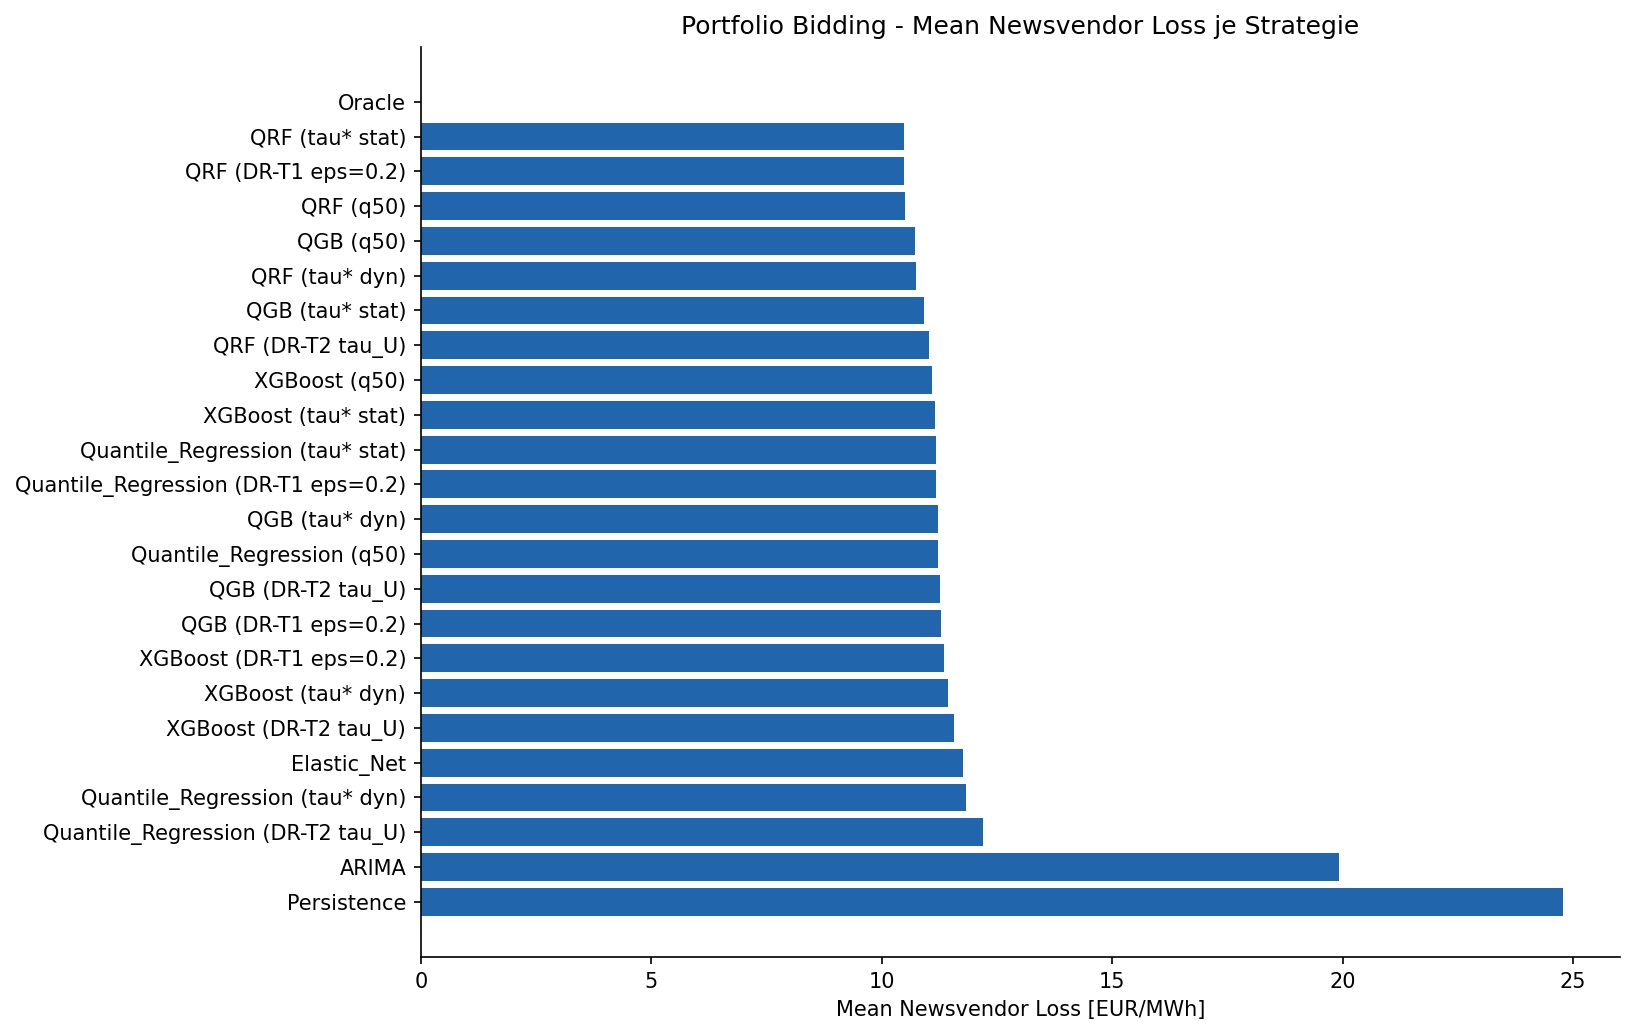

Saved figure


In [8]:
port = results_df[results_df["scenario"] == "Portfolio"].sort_values("mean_nv_loss")
fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#888888" if m == "Oracle" else "#2166ac" for m in port["model"]]
ax.barh(port["model"], port["mean_nv_loss"], color=colors)
ax.set_xlabel("Mean Newsvendor Loss [EUR/MWh]")
ax.set_title("Portfolio Bidding - Mean Newsvendor Loss je Strategie")
ax.invert_yaxis(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "bidding_portfolio_nvloss.png", dpi=150); plt.show()
print("Saved figure")

## 7b. Plot: Portfolio NV-Loss je Modell (nur q50, schlanker Vergleich fuer subsec:ftb/decision)

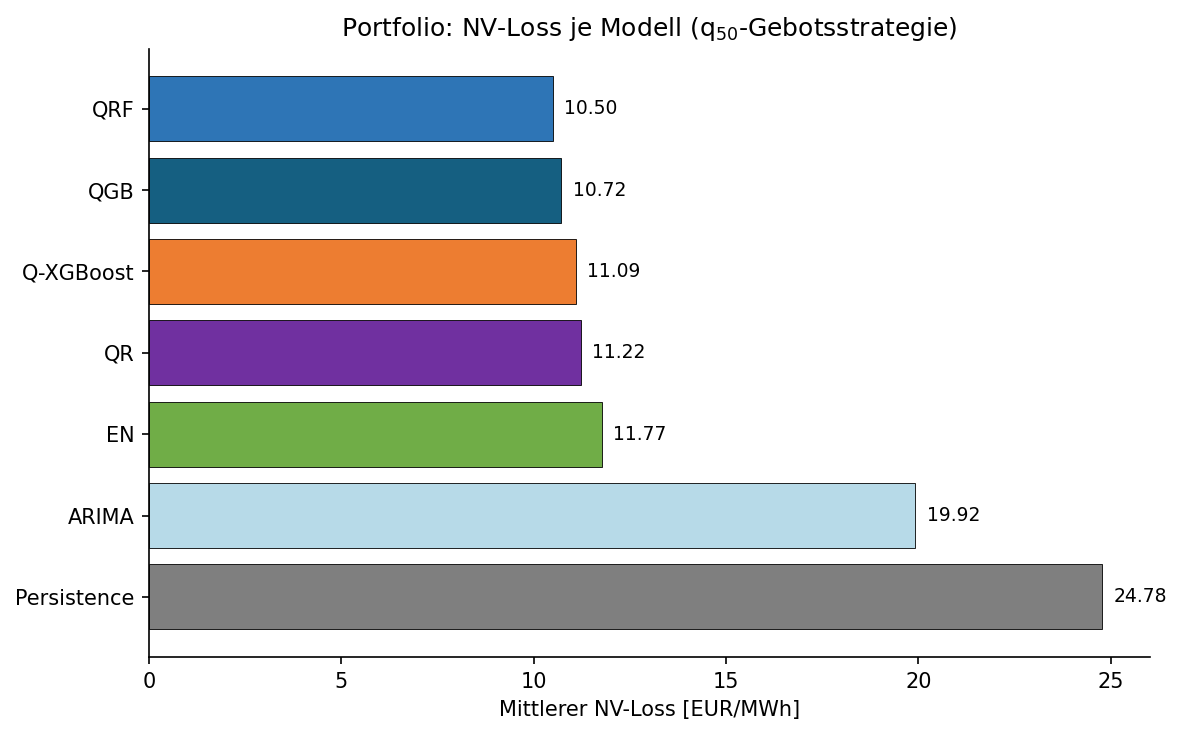

      label  mean_nv_loss
        QRF     10.499321
        QGB     10.715150
  Q-XGBoost     11.092727
         QR     11.220313
         EN     11.768213
      ARIMA     19.917194
Persistence     24.781820


In [9]:
q50_labels = {
    "Persistence": "Persistence", "ARIMA": "ARIMA", "Elastic_Net": "EN",
    "QGB (q50)": "QGB", "QRF (q50)": "QRF", "XGBoost (q50)": "Q-XGBoost",
    "Quantile_Regression (q50)": "QR",
}
port_q50 = results_df[(results_df["scenario"] == "Portfolio") & (results_df["model"].isin(q50_labels.keys()))].copy()
port_q50["label"] = port_q50["model"].map(q50_labels)
port_q50 = port_q50.sort_values("mean_nv_loss")

fig, ax = plt.subplots(figsize=(8, 5))
colors = [get_model_color(m) for m in port_q50["label"]]
ax.barh(port_q50["label"], port_q50["mean_nv_loss"], color=colors, edgecolor="black", linewidth=0.4)
for i, (lbl, v) in enumerate(zip(port_q50["label"], port_q50["mean_nv_loss"])):
    ax.text(v + 0.3, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlabel("Mittlerer NV-Loss [EUR/MWh]")
ax.set_title("Portfolio: NV-Loss je Modell (q$_{50}$-Gebotsstrategie)")
ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "portfolio_q50_by_model.png", dpi=150); plt.show()
print(port_q50[["label", "mean_nv_loss"]].to_string(index=False))

## 8. Forecast-Genauigkeit (MAE / Pinball)

In [10]:
# Forecast-Genauigkeit je Modell (MAE + mean Pinball)
from sklearn.metrics import mean_absolute_error
pb = pd.read_csv(TABLES_DIR / "pinball_evaluation.csv")
pb_mean = pb.groupby("model")["pinball_loss"].mean()  # Mittel über alle Quantile und Standorte
print(pb_mean.sort_values())
acc_rows = []
for site in SITES:
    d = fc[fc["site"] == site]; y = d["y_true"].values
    for col, name in [("persistence", "Persistence"), ("arima", "ARIMA"), ("elastic_net", "Elastic_Net")]:
        acc_rows.append({"model": name, "MAE": mean_absolute_error(y, d[col].values)})
    for mdl, name in PROB_MODELS.items():
        acc_rows.append({"model": name, "MAE": mean_absolute_error(y, d[f"{mdl}_q50"].values)})
acc_df = pd.DataFrame(acc_rows).groupby("model")["MAE"].mean().reset_index()
acc_df["Pinball"] = acc_df["model"].map({"XGBoost": pb_mean.get("xgb"), "QGB": pb_mean.get("qgb"), "QRF": pb_mean.get("qrf")})
print("Forecast-Genauigkeit (Mittel ueber Standorte):")
print(acc_df.round(4).to_string(index=False))

model
qgb    0.098442
xgb    0.100269
qr     0.101352
qrf    0.102263
Name: pinball_loss, dtype: float64
Forecast-Genauigkeit (Mittel ueber Standorte):
              model    MAE  Pinball
              ARIMA 0.4356      NaN
        Elastic_Net 0.3016      NaN
        Persistence 0.5295      NaN
                QGB 0.2730   0.0984
                QRF 0.2757   0.1023
Quantile_Regression 0.2898      NaN
            XGBoost 0.2790   0.1003


## 9. Decision-aware: Genauigkeit vs. oekonomischer Wert

              model  pinball_tau_star  econ_nv_loss
                QGB            0.1341        3.1666
                QRF            0.1352        3.1931
            XGBoost            0.1361        3.2126
Quantile_Regression            0.1418        3.3489
        Elastic_Net            0.1519        3.5870
              ARIMA            0.2185        5.1583
        Persistence            0.2648        6.2522

Spearman(Pinball@tau*, NV-Loss) = 1.000
Bestes nach Genauigkeit: QGB  |  Bestes oekonomisch: QGB
-> identisch


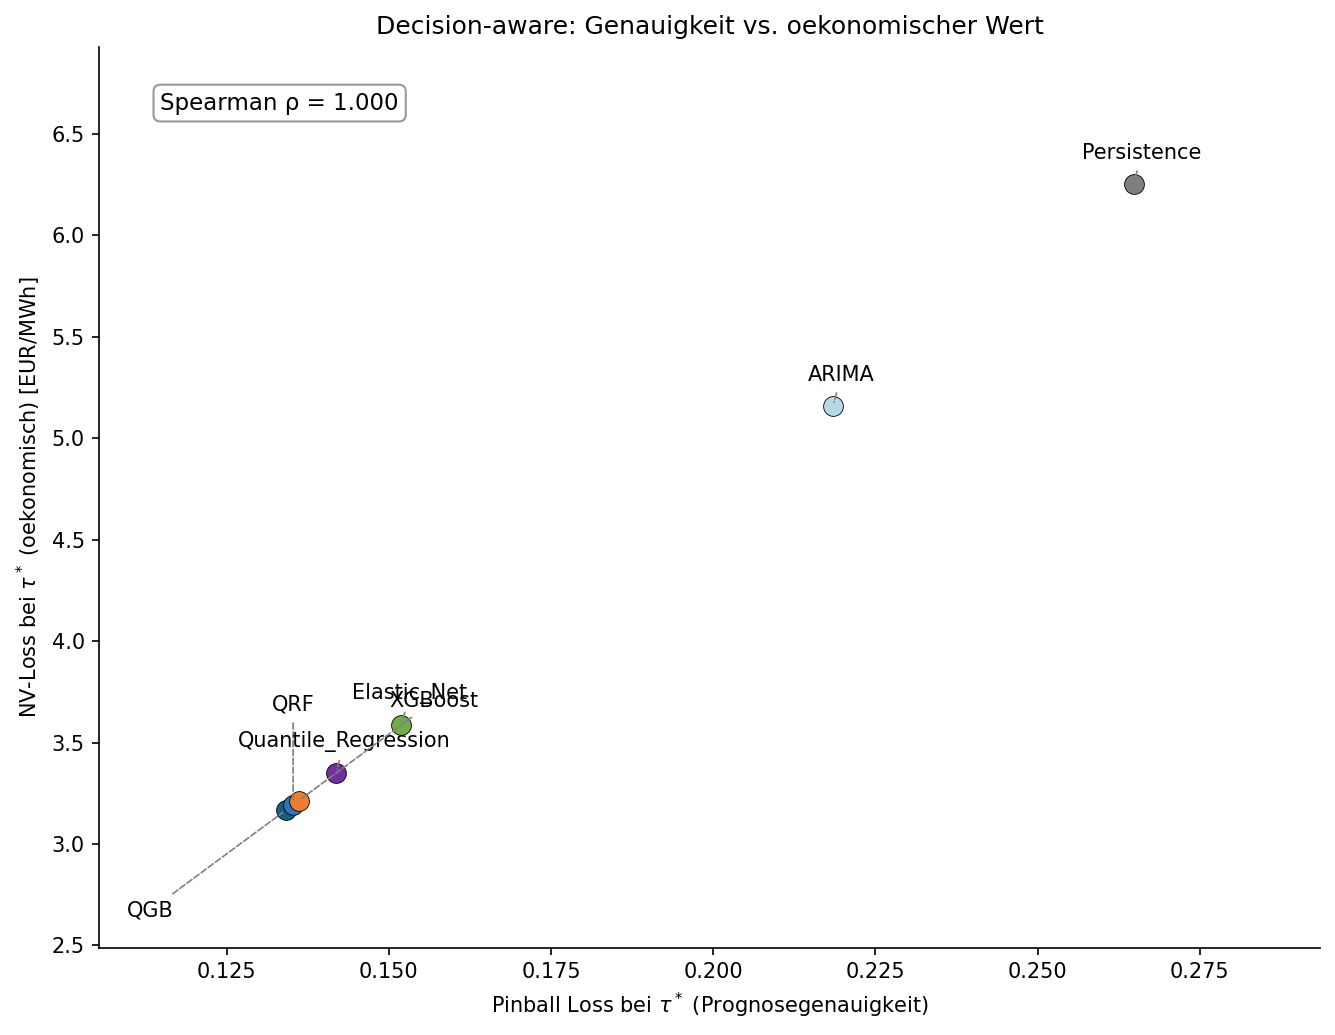

In [11]:
# Decision-aware: Genauigkeit vs. oekonomischer Wert
def base_model(m):
    for k in ["Persistence", "ARIMA", "Elastic_Net", "Quantile_Regression", "XGBoost", "QGB", "QRF"]:
        if m.startswith(k): return k
    return m
econ = results_df[(results_df["model"] != "Oracle") & (results_df["scenario"] != "Portfolio")].copy()
econ["base"] = econ["model"].apply(base_model)
econ_best = econ.groupby("base")["mean_nv_loss"].min().reset_index().rename(columns={"base": "model", "mean_nv_loss": "econ_nv_loss"})

# --- Konsistente Genauigkeitsmetrik: Pinball Loss bei tau* (statt MAE) ---
# MAE ist nur fuer Punktprognosen definiert; ein "MAE des q50-Quantils" wirft bei
# probabilistischen Modellen deren Verteilungsinformation weg und ist mit dem
# reinen Punkt-MAE nicht direkt vergleichbar. Pinball Loss bei tau* ist fuer beide
# Modelltypen einheitlich definiert: fuer Punktmodelle wird die Punktprognose als
# tau*-Quantilschaetzung behandelt, fuer Quantilmodelle wird die (interpolierte)
# tau*-Quantilprognose (qbid) verwendet. x- UND y-Achse werden konsistent als
# Standort-Mittelwert (nicht Minimum/Bestfall) berechnet, beide bezogen auf
# dieselbe tau*-Strategie.
def pinball_loss(y, yhat, tau):
    e = y - yhat
    return np.mean(np.maximum(tau * e, (tau - 1) * e))

POINT_COLS_DA = {"Persistence": "persistence", "ARIMA": "arima", "Elastic_Net": "elastic_net"}
acc_rows = []
for site in SITES:
    d = fc[fc["site"] == site]; y = d["y_true"].values
    for name, col in POINT_COLS_DA.items():
        acc_rows.append({"site": site, "model": name, "pinball_tau_star": pinball_loss(y, d[col].values, tau_star)})
    for prefix, name in PROB_MODELS.items():
        yhat = qbid(d, prefix, tau_star)
        acc_rows.append({"site": site, "model": name, "pinball_tau_star": pinball_loss(y, yhat, tau_star)})
acc_tau_df = pd.DataFrame(acc_rows).groupby("model")["pinball_tau_star"].mean().reset_index()

# y-Achse passend dazu: mean_nv_loss der "(tau* stat)"-Strategie (Punktmodelle: einzige Strategie),
# Mittelwert ueber die 4 Standorte -- nicht das Minimum ueber Standorte/Strategien wie econ_best.
tau_star_model_map = {
    "Persistence": "Persistence", "ARIMA": "ARIMA", "Elastic_Net": "Elastic_Net",
    "QGB (tau* stat)": "QGB", "QRF (tau* stat)": "QRF",
    "XGBoost (tau* stat)": "XGBoost", "Quantile_Regression (tau* stat)": "Quantile_Regression",
}
econ_tau = results_df[(results_df["scenario"] != "Portfolio") & (results_df["model"].isin(tau_star_model_map.keys()))].copy()
econ_tau["model"] = econ_tau["model"].map(tau_star_model_map)
econ_tau_avg = econ_tau.groupby("model")["mean_nv_loss"].mean().reset_index().rename(columns={"mean_nv_loss": "econ_nv_loss"})

merged = acc_tau_df.merge(econ_tau_avg, on="model", how="inner")
assert len(merged) == 7, f"Erwarte 7 Modelle, habe {len(merged)}: {merged['model'].tolist()}"

def spearman(a, b):
    ra = pd.Series(a).rank().values; rb = pd.Series(b).rank().values
    return float(np.corrcoef(ra, rb)[0, 1])
rho = spearman(merged["pinball_tau_star"], merged["econ_nv_loss"])
best_acc = merged.loc[merged["pinball_tau_star"].idxmin(), "model"]
best_econ = merged.loc[merged["econ_nv_loss"].idxmin(), "model"]
print(merged.sort_values("pinball_tau_star").round(4).to_string(index=False))
print(f"\nSpearman(Pinball@tau*, NV-Loss) = {rho:.3f}")
print(f"Bestes nach Genauigkeit: {best_acc}  |  Bestes oekonomisch: {best_econ}")
print("-> identisch" if best_acc == best_econ else "-> DIVERGENZ: decision-aware Auswahl waehlt ein anderes Modell!")

# Automatische Label-Platzierung mit gestrichelten Leader-Lines (plot_utils.annotate_with_leaders):
# isolierte Punkte bekommen einen kleinen festen Versatz, dicht beieinanderliegende
# Punkte werden radial um ihren Cluster-Schwerpunkt in 8 Himmelsrichtungen
# aufgefaechert -- keine hartkodierten Koordinaten.
fig, ax = plt.subplots(figsize=(9, 7))
annotate_with_leaders(ax, merged["pinball_tau_star"], merged["econ_nv_loss"], merged["model"], cluster_gap=0.16)
ax.margins(x=0.22, y=0.22)
ax.text(0.05, 0.95, f"Spearman ρ = {rho:.3f}", transform=ax.transAxes, fontsize=11,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8))
ax.set_xlabel(r"Pinball Loss bei $\tau^*$ (Prognosegenauigkeit)")
ax.set_ylabel("NV-Loss bei $\\tau^*$ (oekonomisch) [EUR/MWh]")
ax.set_title("Decision-aware: Genauigkeit vs. oekonomischer Wert")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "decision_aware_accuracy_vs_economics.png", dpi=150); plt.show()

## 10. Interpretierbar vs. Black-Box

                   min   mean
group                        
black-box        1.992  2.009
interpretierbar  1.982  2.909

Hinweis: interpretierbar = Persistence/ARIMA/Elastic_Net (Punkt) + Quantile_Regression (probabilistisch, taeglich neu gefittet in NB03).


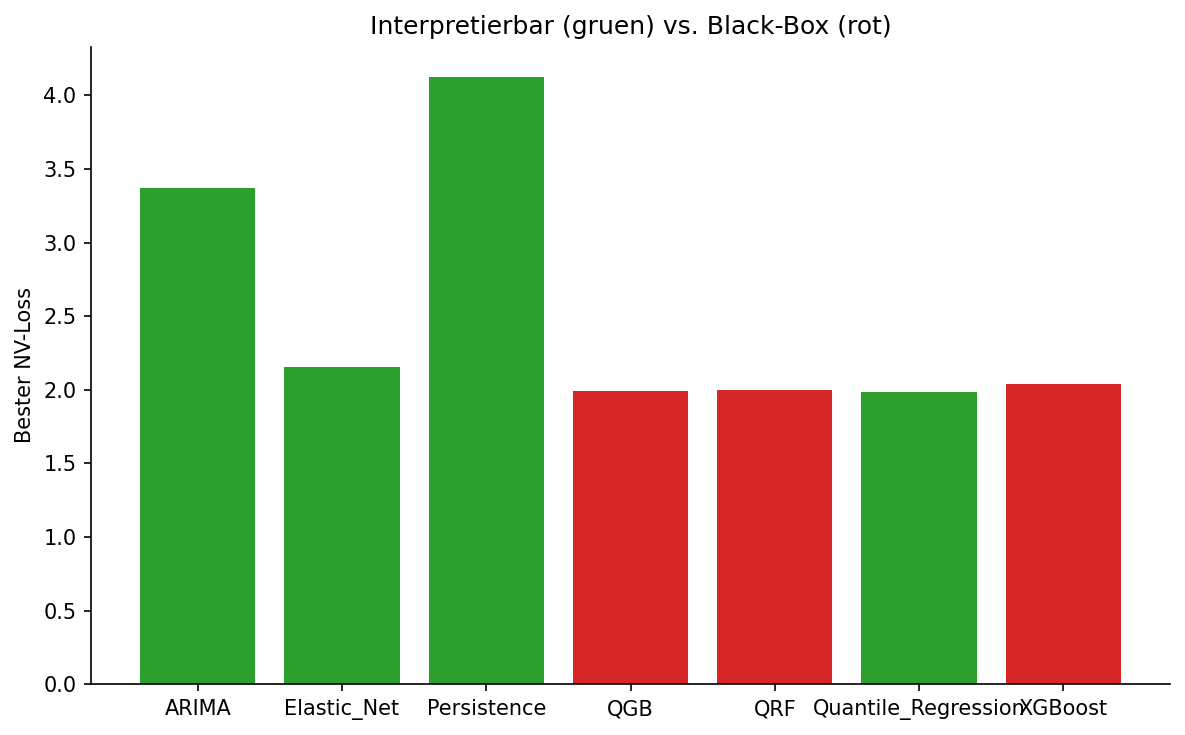

In [12]:
# Interpretierbar vs. Black-Box (oekonomisch)
GROUPS = {"Persistence": "interpretierbar", "ARIMA": "interpretierbar", "Elastic_Net": "interpretierbar", "Quantile_Regression": "interpretierbar",
          "XGBoost": "black-box", "QGB": "black-box", "QRF": "black-box"}
econ_best["group"] = econ_best["model"].map(GROUPS)
print(econ_best.groupby("group")["econ_nv_loss"].agg(["min", "mean"]).round(3))
print("\nHinweis: interpretierbar = Persistence/ARIMA/Elastic_Net (Punkt) + Quantile_Regression (probabilistisch, taeglich neu gefittet in NB03).")
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2ca02c" if GROUPS[m] == "interpretierbar" else "#d62728" for m in econ_best["model"]]
ax.bar(econ_best["model"], econ_best["econ_nv_loss"], color=colors)
ax.set_ylabel("Bester NV-Loss"); ax.set_title("Interpretierbar (gruen) vs. Black-Box (rot)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "interpretable_vs_blackbox.png", dpi=150); plt.show()

## 11. Point vs Probabilistic (oekonomisch)

In [13]:
# Point vs Probabilistic (oekonomisch)
point_econ = econ[econ["base"].isin(["Persistence", "ARIMA", "Elastic_Net"])].groupby("base")["mean_nv_loss"].min()
prob_econ = econ[econ["base"].isin(["XGBoost", "QGB", "QRF"]) & econ["model"].str.contains("tau")].groupby("base")["mean_nv_loss"].min()
print("Point-Gebote (direkt):"); print(point_econ.round(3))
print("\nProbabilistic (tau*-Gebote):"); print(prob_econ.round(3))
bp, bq = float(point_econ.min()), float(prob_econ.min())
print(f"\nBester Point: {bp:.3f}  |  Bester Probabilistic: {bq:.3f}")
print(f"Oekonomischer Vorteil probabilistisch: {100*(bp-bq)/bp:.1f}% niedrigerer NV-Loss")

Point-Gebote (direkt):
base
ARIMA          3.374
Elastic_Net    2.157
Persistence    4.125
Name: mean_nv_loss, dtype: float64

Probabilistic (tau*-Gebote):
base
QGB        1.992
QRF        1.997
XGBoost    2.037
Name: mean_nv_loss, dtype: float64

Bester Point: 2.157  |  Bester Probabilistic: 1.992
Oekonomischer Vorteil probabilistisch: 7.6% niedrigerer NV-Loss


## 12. Risk Exposure + Bidding-Detail

      plant         bid  mean_profit  CVaR5_profit  mean_nv_loss  p95_nv_loss  max_imbalance
     Obbach Elastic_Net       59.284      -110.372         4.168       11.702          3.290
     Obbach       ARIMA       62.076      -148.723         6.007       15.057          2.268
     Obbach    QGB_tau*       59.197       -90.716         3.738       11.965          2.109
     Obbach     QR_tau*       58.941       -92.044         3.973       11.620          5.690
 Schonungen Elastic_Net       24.030       -38.721         2.157        6.831          8.045
 Schonungen       ARIMA       24.290       -63.599         3.374        9.754          2.202
 Schonungen    QGB_tau*       23.961       -32.856         1.992        7.201          1.973
 Schonungen     QR_tau*       23.747       -33.914         1.982        6.915          8.094
 Schwanfeld Elastic_Net       43.321       -85.147         4.439       13.663         11.613
 Schwanfeld       ARIMA       43.788      -113.706         6.127      

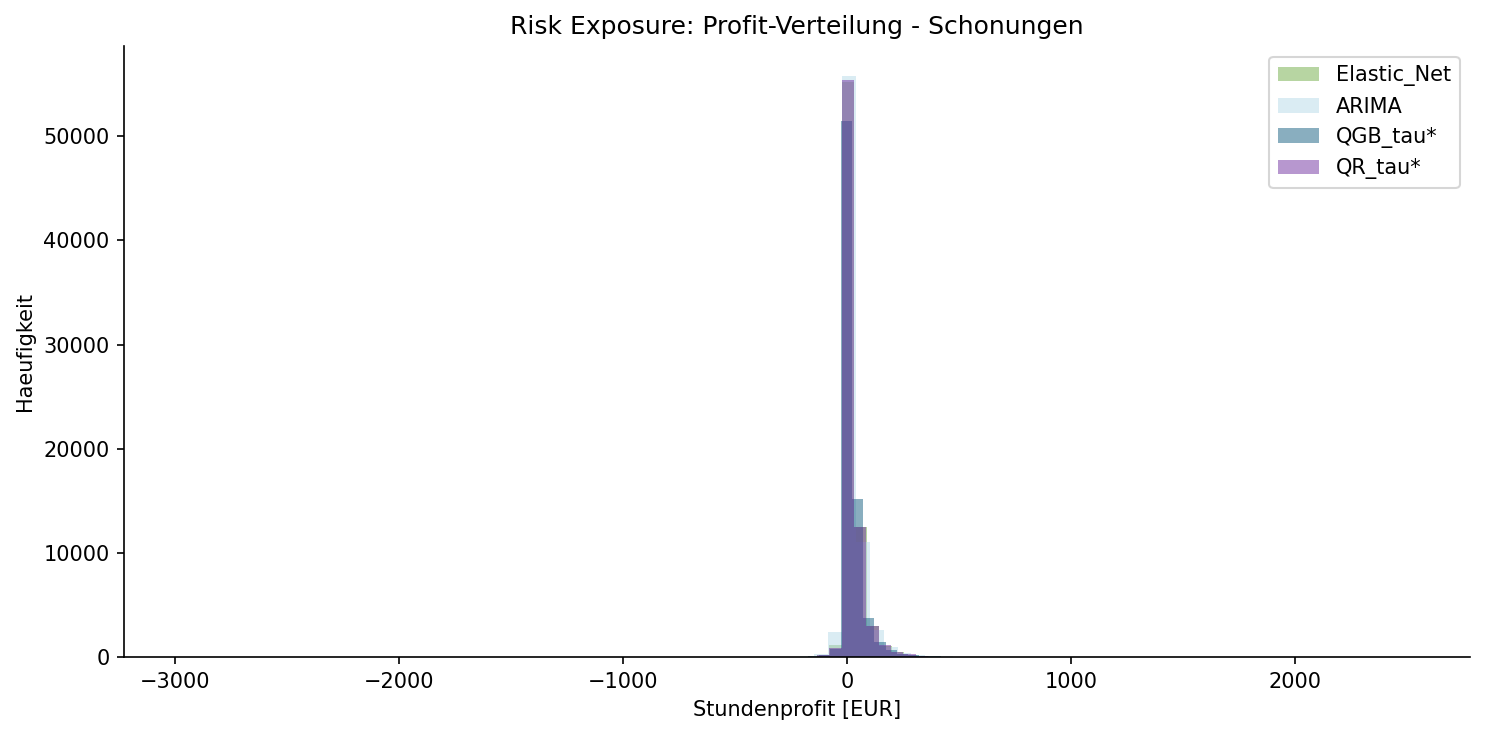

In [14]:
# Risk Exposure + per-Stunde Bidding-Detail speichern (fuer NB05-Fehleranalyse)
risk_rows = []
for site in SITES:
    dd = fc[fc["site"] == site].merge(prices[["timestamp", "rebap", "da_price"]], on="timestamp", how="inner").reset_index(drop=True)
    if len(dd) == 0: continue
    y, p_da, p_re = dd["y_true"].values, dd["da_price"].values, dd["rebap"].values
    bids = {"Elastic_Net": dd["elastic_net"].values, "ARIMA": dd["arima"].values,
            "QGB_tau*": qbid(dd, "qgb", tau_star), "QR_tau*": qbid(dd, "qr", tau_star)}
    for label, bid in bids.items():
        b = np.clip(bid, 0, None)
        nv = loss(b, y, c_under, c_over); pr = profit(b, y, p_da, p_re)
        k = max(1, int(0.05 * len(pr)))
        risk_rows.append({"plant": site, "bid": label, "mean_profit": pr.mean(),
                          "CVaR5_profit": float(np.sort(pr)[:k].mean()),
                          "mean_nv_loss": nv.mean(), "p95_nv_loss": float(np.percentile(nv, 95)),
                          "max_imbalance": float(np.max(np.abs(b - y)))})
    detail = []
    for label, prefix in [("QGB", "qgb"), ("QR", "qr")]:
        bidq = np.clip(qbid(dd, prefix, tau_star), 0, None)
        detail.append(pd.DataFrame({"timestamp": dd["timestamp"], "model": label, "y_true": y, "bid": bidq,
                      "nv_loss": loss(bidq, y, c_under, c_over),
                      "q_spread": (dd[f"{prefix}_q90"] - dd[f"{prefix}_q10"]).values}))
    pd.concat(detail, ignore_index=True).to_csv(FORECAST_DIR / f"bidding_detail_{site.lower()}.csv", index=False)
risk_df = pd.DataFrame(risk_rows)
risk_df.to_csv(TABLES_DIR / "risk_metrics.csv", index=False)
print(risk_df.round(3).to_string(index=False))

dfp = fc[fc["site"] == "Schonungen"].merge(prices[["timestamp", "rebap", "da_price"]], on="timestamp", how="inner")
y = dfp["y_true"].values
fig, ax = plt.subplots(figsize=(10, 5))
for label, bid, c in [("Elastic_Net", dfp["elastic_net"].values, MODEL_COLORS["elastic_net"]),
                       ("ARIMA", dfp["arima"].values, MODEL_COLORS["arima"]),
                       ("QGB_tau*", qbid(dfp, "qgb", tau_star), MODEL_COLORS["qgb"]),
                       ("QR_tau*", qbid(dfp, "qr", tau_star), MODEL_COLORS["qr"])]:
    pr = profit(np.clip(bid, 0, None), y, dfp["da_price"].values, dfp["rebap"].values)
    ax.hist(pr, bins=80, alpha=0.5, label=label, color=c)
ax.set_xlabel("Stundenprofit [EUR]"); ax.set_ylabel("Haeufigkeit")
ax.set_title("Risk Exposure: Profit-Verteilung - Schonungen"); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "risk_profit_distribution.png", dpi=150); plt.show()

## 13. Cross-Site: Forecast-Genauigkeit (Point | Probabilistic getrennt)

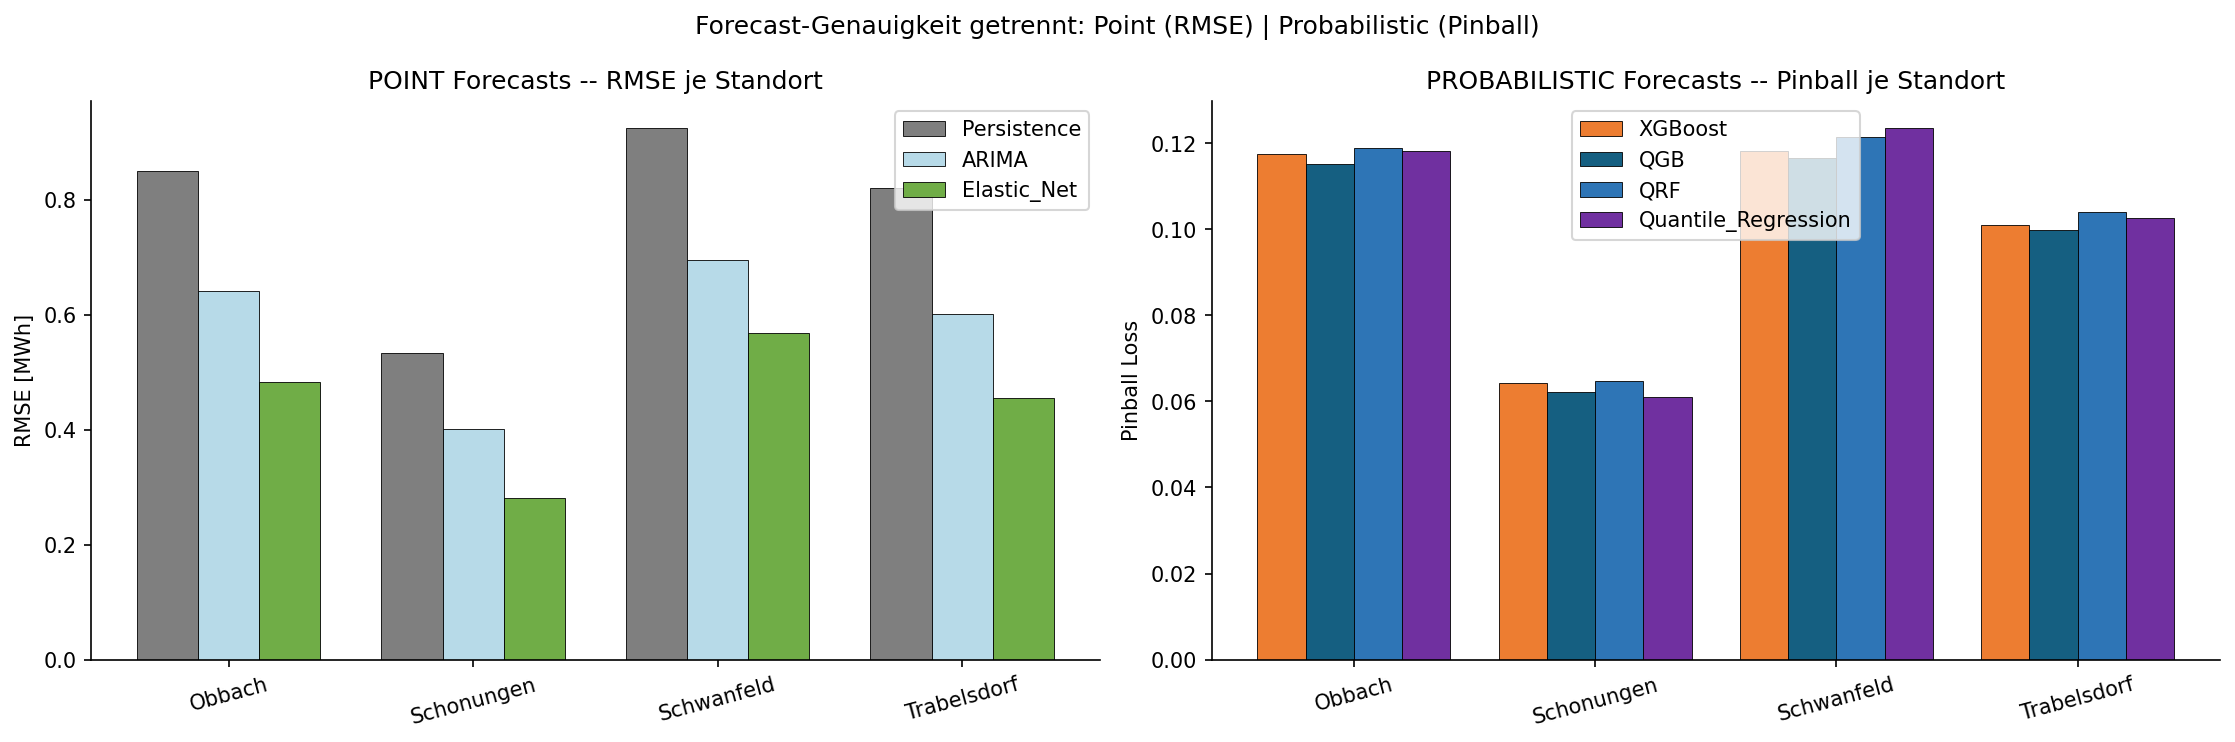

In [15]:
# Cross-Site Forecast-Genauigkeit -- Point (RMSE) und Probabilistic (Pinball) GETRENNT
sites = sorted(fc["site"].unique())
POINT_COLS = {"persistence": "Persistence", "arima": "ARIMA", "elastic_net": "Elastic_Net"}
PROB_LBL = {"xgb": "XGBoost", "qgb": "QGB", "qrf": "QRF", "qr": "Quantile_Regression"}

# Point: RMSE je Standort
pt = []
for s in sites:
    d = fc[fc["site"] == s]
    y = d["y_true"].values
    for c, n in POINT_COLS.items():
        pt.append({
            "site": s,
            "model": n,
            "RMSE": float(np.sqrt(np.mean((d[c].values - y) ** 2)))
        })
pt = pd.DataFrame(pt)

# Probabilistic: Pinball je Standort
pb = pd.read_csv(TABLES_DIR / "pinball_evaluation.csv")
pbp = pb.groupby(["plant", "model"])["pinball_loss"].mean().reset_index()
pbp["model"] = pbp["model"].map(PROB_LBL)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(sites))

w_point = 0.25
w_prob = 0.20   # bei 4 Modellen etwas schmaler

# POINT
for i, (c, n) in enumerate(POINT_COLS.items()):
    vals = [pt[(pt["site"] == s) & (pt["model"] == n)]["RMSE"].values[0] for s in sites]
    axes[0].bar(
        x + (i - 1) * w_point,
        vals,
        w_point,
        label=n,
        color=get_model_color(n),
        edgecolor="black",
        linewidth=0.4
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(sites, rotation=15)
axes[0].set_ylabel("RMSE [MWh]")
axes[0].set_title("POINT Forecasts -- RMSE je Standort")
axes[0].legend()

# PROBABILISTIC
for i, (c, n) in enumerate(PROB_LBL.items()):
    vals = [
        pbp[(pbp["plant"] == s) & (pbp["model"] == n)]["pinball_loss"].values[0]
        if len(pbp[(pbp["plant"] == s) & (pbp["model"] == n)]) else np.nan
        for s in sites
    ]
    axes[1].bar(
        x + (i - 1.5) * w_prob,
        vals,
        w_prob,
        label=n,
        color=get_model_color(n),
        edgecolor="black",
        linewidth=0.4
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(sites, rotation=15)
axes[1].set_ylabel("Pinball Loss")
axes[1].set_title("PROBABILISTIC Forecasts -- Pinball je Standort")
axes[1].legend()

plt.suptitle("Forecast-Genauigkeit getrennt: Point (RMSE) | Probabilistic (Pinball)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "crosssite_forecast_accuracy.png", dpi=150)
plt.show()

## 14. Cross-Site: Oekonomie (Point vs Probabilistic)

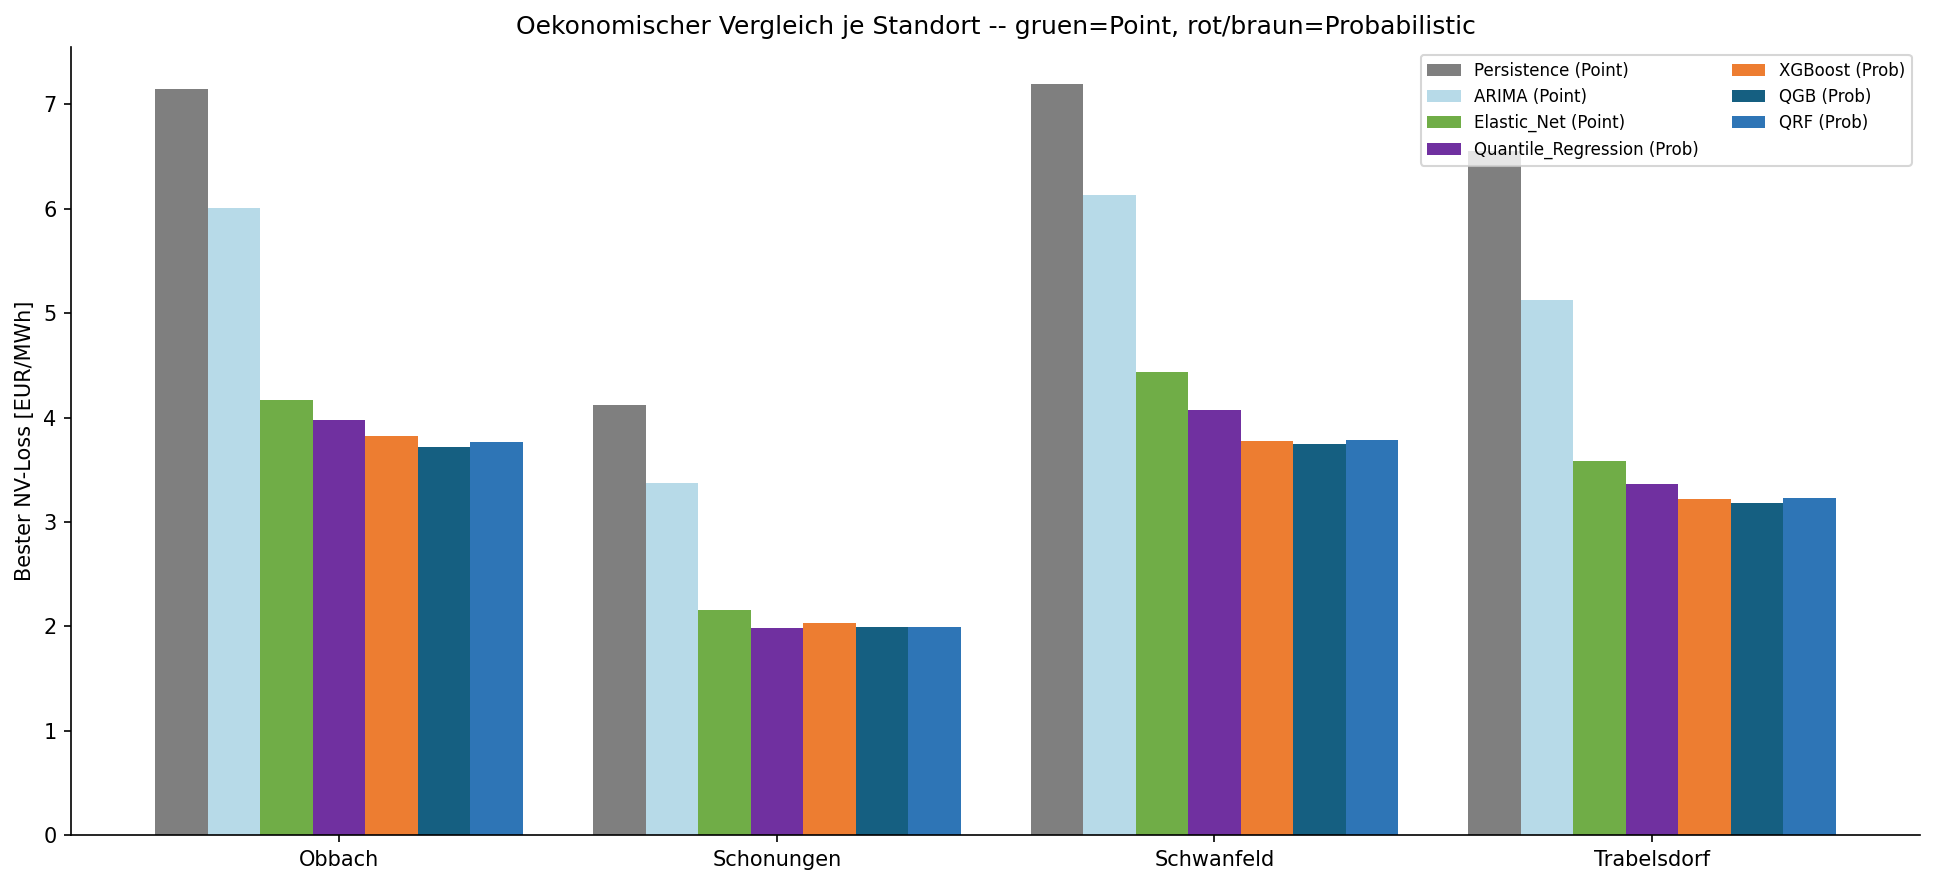

Probabilistische tau*-Gebote (rot/braun/lila, lila=Quantile_Regression) durchgaengig niedrigerer NV-Loss als Point (gruen)


In [16]:
# Cross-Site Oekonomie -- Point vs Probabilistic (kombiniert nur im Bidding-Kontext)
def base_model(m):
    for k in ["Persistence", "ARIMA", "Elastic_Net", "Quantile_Regression", "XGBoost", "QGB", "QRF"]:
        if m.startswith(k): return k
    return m
econ2 = results_df[(results_df["model"] != "Oracle") & (results_df["scenario"] != "Portfolio")].copy()
econ2["base"] = econ2["model"].apply(base_model)
best = econ2.groupby(["scenario", "base"])["mean_nv_loss"].min().reset_index()
PTYPE = {"Persistence": "Point", "ARIMA": "Point", "Elastic_Net": "Point", "Quantile_Regression": "Prob", "XGBoost": "Prob", "QGB": "Prob", "QRF": "Prob"}
COL = {"Persistence": MODEL_COLORS["persistence"], "ARIMA": MODEL_COLORS["arima"], "Elastic_Net": MODEL_COLORS["elastic_net"], "Quantile_Regression": MODEL_COLORS["Quantile_Regression"], "XGBoost": MODEL_COLORS["xgb"], "QGB": MODEL_COLORS["qgb"], "QRF": MODEL_COLORS["qrf"]}
sites = sorted(best["scenario"].unique()); bases = ["Persistence", "ARIMA", "Elastic_Net", "Quantile_Regression", "XGBoost", "QGB", "QRF"]
fig, ax = plt.subplots(figsize=(13, 6)); x = np.arange(len(sites)); w = 0.12
for i, b in enumerate(bases):
    vals = [best[(best["scenario"] == s) & (best["base"] == b)]["mean_nv_loss"].values[0] if len(best[(best["scenario"] == s) & (best["base"] == b)]) else np.nan for s in sites]
    ax.bar(x + (i - (len(bases) - 1) / 2) * w, vals, w, label=f"{b} ({PTYPE[b]})", color=COL[b])
ax.set_xticks(x); ax.set_xticklabels(sites); ax.set_ylabel("Bester NV-Loss [EUR/MWh]")
ax.set_title("Oekonomischer Vergleich je Standort -- gruen=Point, rot/braun=Probabilistic")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
plt.savefig(FIGURES_DIR / "crosssite_economic_point_vs_prob.png", dpi=150); plt.show()
print("Probabilistische tau*-Gebote (rot/braun/lila, lila=Quantile_Regression) durchgaengig niedrigerer NV-Loss als Point (gruen)")